# MLFLOW setup in Jupyter Notebook

This notebook contains a small Data Science Project where MLFlow is used to log all Feature Engineering and Modeling Parameters as well as Metrics.



## Loading Data

In [ ]:
import sys
# adding to the path variables the one folder higher (locally, not changing system variables)
sys.path.append("..")
import pandas as pd
import numpy as np
import warnings
import mlflow

from modeling.config import EXPERIMENT_NAME
TRACKING_URI = open("../.mlflow_uri").read().strip()

warnings.filterwarnings('ignore')

# coffee data
url="https://github.com/jldbc/coffee-quality-database/raw/master/data/robusta_data_cleaned.csv"
coffee_features=pd.read_csv(url)

# coffee score
url="https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/robusta_ratings_raw.csv"
coffee_quality=pd.read_csv(url)

In [ ]:
coffee_features.head()

In [ ]:
coffee_quality.head()

In [ ]:
Y = coffee_quality["quality_score"]

## Data cleaning and feature engineering

In [ ]:
coffee_features.info()

In [ ]:
#for this exercise we will only deal with numeric variables

X = coffee_features.select_dtypes(['number'])

## Splitting data for testing 

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [ ]:
#dropping Quakers column and unnamed
#changing one of the altitude to log and droping the original
X_train["altitude_mean_log"] = np.log(X_train["altitude_mean_meters"])
X_train.drop(['altitude_mean_meters'], axis=1, inplace=True)
X_train.drop(['Quakers'], axis=1, inplace=True)
X_train.drop(['Unnamed: 0'], axis=1, inplace=True)

In [ ]:
X_train.info()

In [ ]:
altitude_low_meters_mean = X_train["altitude_low_meters"].mean()
altitude_high_meters_mean = X_train["altitude_high_meters"].mean()
altitude_mean_log_mean = X_train["altitude_mean_log"].mean()

In [ ]:
# fillna with mean.. 
X_train["altitude_low_meters"] = X_train["altitude_low_meters"].fillna(altitude_low_meters_mean)
X_train["altitude_high_meters"] = X_train["altitude_high_meters"].fillna(altitude_high_meters_mean)
X_train["altitude_mean_log"] = X_train["altitude_mean_log"].fillna(altitude_mean_log_mean)

In [ ]:
print(f"altitude low meters mean is {altitude_low_meters_mean}")
print(f"altitude_high_meters_mean is {altitude_high_meters_mean}")
print(f"altitude_mean_log_mean is {altitude_mean_log_mean}")

## Trainining the model and tracking with MLFlow

In [ ]:
# setting the MLFlow connection and experiment
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
mlflow.start_run()
run = mlflow.active_run()

In [ ]:
print("Active run_id: {}".format(run.info.run_id))

In [ ]:
#training the model
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)

In [ ]:
#model metric on training data
from sklearn.metrics import mean_squared_error
y_train_pred = reg.predict(X_train)
mse_train = mean_squared_error(y_train, y_train_pred)
print(mse_train)

In [ ]:
# feature engineering of test data
#dropping Quakers column and unnamed
#changing one of the altitude to log and droping the original
X_test["altitude_mean_log"] = np.log(X_test["altitude_mean_meters"])
X_test.drop(['altitude_mean_meters'], axis=1, inplace=True)
X_test.drop(['Quakers'], axis=1, inplace=True)
X_test.drop(['Unnamed: 0'], axis=1, inplace=True)
# fillna with mean.. 
X_test["altitude_low_meters"] = X_test["altitude_low_meters"].fillna(altitude_low_meters_mean)
X_test["altitude_high_meters"] = X_test["altitude_high_meters"].fillna(altitude_high_meters_mean)
X_test["altitude_mean_log"] = X_test["altitude_mean_log"].fillna(altitude_mean_log_mean)

In [ ]:
#model metric on test data
y_test_pred = reg.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
print(mse_test)

In [ ]:
#seting parameters that should be logged on MLFlow
#these parameters were used in feature engineering (inputing missing values)
#or parameters of the model (fit_intercept for Linear Regression model)
params = {
      "altitude_low_meters_mean": altitude_low_meters_mean,
      "altitude_high_meters_mean": altitude_high_meters_mean,
      "altitude_mean_log_mean": altitude_mean_log_mean,
      "fit_intercept": True,
  }

In [ ]:
#logging params to mlflow
mlflow.log_params(params)
#setting tags
mlflow.set_tag("running_from_jupyter", "True")
#logging metrics
mlflow.log_metric("train-" + "MSE", mse_train)
mlflow.log_metric("test-" + "MSE", mse_test)
# logging the model to mlflow will not work without a AWS Connection setup.. too complex for now
# but possible if running mlflow locally
# mlflow.log_artifact("../models")
# mlflow.sklearn.log_model(reg, "model")
mlflow.end_run()

In [ ]:
mlflow.get_run(run_id=run.info.run_id)

## Checking the experiments

while the next cell is running you will not be able to run other cells in the notebook

In [ ]:
!mlflow ui

In [ ]:
####

In [1]:
import duckdb
import pandas as pd
import openmeteo_requests
import requests_cache
from retry_requests import retry

# Day-ahead prices (forecasted)
prices = pd.concat([
    pd.read_csv("../data/Day-ahead_prices_201901010000_202201010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Day-ahead_prices_202201010000_202501010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Day-ahead_prices_202501010000_202603060000_Hour.csv", sep=";")
], ignore_index=True)

# Consumption
consumption = pd.concat([
    pd.read_csv("../data/Forecasted_consumption_201901010000_202201010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Forecasted_consumption_202201010000_202501010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Forecasted_consumption_202501010000_202603060000_Hour.csv", sep=";")
], ignore_index=True)

# Generation
generation = pd.concat([
    pd.read_csv("../data/Forecasted_generation_Day-Ahead_201901010000_202201010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Forecasted_generation_Day-Ahead_202201010000_202501010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Forecasted_generation_Day-Ahead_202501010000_202603060000_Hour.csv", sep=";")
], ignore_index=True)

print(f"Prices:     {prices.shape}")
print(f"Consumption:{consumption.shape}")
print(f"Generation: {generation.shape}")

Prices:     (62904, 19)
Consumption:(62904, 4)
Generation: (62904, 8)


In [2]:
# checking the data

In [3]:
prices.head(2)

,Start date,End date,Germany/Luxembourg [€/MWh] Calculated resolutions,∅ DE/LU neighbours [€/MWh] Calculated resolutions,Belgium [€/MWh] Calculated resolutions,Denmark 1 [€/MWh] Calculated resolutions,Denmark 2 [€/MWh] Calculated resolutions,France [€/MWh] Calculated resolutions,Netherlands [€/MWh] Calculated resolutions,Norway 2 [€/MWh] Calculated resolutions,Austria [€/MWh] Calculated resolutions,Poland [€/MWh] Calculated resolutions,Sweden 4 [€/MWh] Calculated resolutions,Switzerland [€/MWh] Calculated resolutions,Czech Republic [€/MWh] Calculated resolutions,DE/AT/LU [€/MWh] Calculated resolutions,Northern Italy [€/MWh] Calculated resolutions,Slovenia [€/MWh] Calculated resolutions,Hungary [€/MWh] Calculated resolutions
0,"Jan 1, 2019 12:00 AM","Jan 1, 2019 1:00 AM",28.32,-,69.49,28.32,28.32,51.0,68.92,48.77,33.48,-,28.32,50.26,8.50,-,51.00,51.0,59.9
1,"Jan 1, 2019 1:00 AM","Jan 1, 2019 2:00 AM",10.07,-,66.58,10.07,10.07,46.27,64.98,49.25,39.76,-,10.07,48.74,3.97,-,46.27,46.27,52.71


In [4]:
consumption.head(2)

,Start date,End date,grid load [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
0,"Jan 1, 2019 12:00 AM","Jan 1, 2019 1:00 AM","43,213.25","19,264.50"
1,"Jan 1, 2019 1:00 AM","Jan 1, 2019 2:00 AM","41,275.75","15,607.00"


In [5]:
generation.head(2)

,Start date,End date,Total [MWh] Calculated resolutions,Photovoltaics and wind [MWh] Calculated resolutions,Wind offshore [MWh] Calculated resolutions,Wind onshore [MWh] Calculated resolutions,Photovoltaics [MWh] Calculated resolutions,Other [MWh] Calculated resolutions
0,"Jan 1, 2019 12:00 AM","Jan 1, 2019 1:00 AM","51,011.46","23,948.75","5,069.00","18,879.75",0.00,"27,062.71"
1,"Jan 1, 2019 1:00 AM","Jan 1, 2019 2:00 AM","51,016.93","25,668.75","5,042.25","20,626.50",0.00,"25,348.18"


In [6]:
# renaming columns

consumption = consumption.rename(columns={"Start date": "timestamp"})
prices = prices.rename(columns={"Start date": "timestamp"})
generation = generation.rename(columns={"Start date": "timestamp"})

In [7]:
# using duckdb to get important features and to join tables; using duckdb instead of pandas because duckdb is much faster than pandas on large datasets, sql is also easier to use using duckdb

df = duckdb.query("""
    SELECT 
        p.timestamp,
        p."Germany/Luxembourg [€/MWh] Calculated resolutions" as price,
        c."grid load [MWh] Calculated resolutions" as load,
        g."Wind offshore [MWh] Calculated resolutions" as wind_offshore,
        g."Wind onshore [MWh] Calculated resolutions" as wind_onshore,
        g."Photovoltaics [MWh] Calculated resolutions" as solar
    FROM prices p
    JOIN consumption c ON p.timestamp = c.timestamp
    JOIN generation g ON p.timestamp = g.timestamp
""").fetchdf()

print(df.head())
print(df.shape)
print(df.isnull().sum()) 

              timestamp  price       load wind_offshore wind_onshore solar
0  Jan 1, 2019 12:00 AM  28.32  43,213.25      5,069.00    18,879.75  0.00
1   Jan 1, 2019 1:00 AM  10.07  41,275.75      5,042.25    20,626.50  0.00
2   Jan 1, 2019 2:00 AM  -4.08  40,187.50      5,028.50    22,355.50  0.00
3   Jan 1, 2019 3:00 AM  -9.91  39,909.00      4,977.75    24,032.50  0.00
4   Jan 1, 2019 4:00 AM  -7.41  40,258.00      4,907.25    25,452.00  0.00
(62946, 6)
timestamp        0
price            0
load             0
wind_offshore    0
wind_onshore     0
solar            0
dtype: int64


In [8]:
df.shape

(62946, 6)

In [9]:
# getting the weather data from openmeteo api

import openmeteo_requests
import requests_cache
from retry_requests import retry
import pandas as pd

cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# taking the average of 4 cities, Cologne because it does not have umlaut rather than Köln, easier writing
cities = {
    "Berlin":  (52.52, 13.41),
    "Munich":  (48.14, 11.58),
    "Hamburg": (53.55, 10.00),
    "Cologne": (50.94,  6.96)
}

weather_dfs = []

# parameters for api
for city, (lat, lon) in cities.items():
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2019-01-01",
        "end_date": "2026-03-05",
        "hourly": [
            "temperature_2m",
            "wind_speed_100m"
        ],
        "timezone": "Europe/Berlin"
    }
    
    responses = openmeteo.weather_api(
        "https://archive-api.open-meteo.com/v1/archive", 
        params=params
    )
    response = responses[0]
    hourly = response.Hourly()
    
    # getting temperatures dataframe
    weather_df = pd.DataFrame({
        "timestamp": pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left"
        ),
        f"temp_{city}":       hourly.Variables(0).ValuesAsNumpy(),
        f"wind_speed_{city}": hourly.Variables(1).ValuesAsNumpy(),
    })
    
    weather_dfs.append(weather_df)
    print(f"✅ {city} downloaded!")

# connecting cities
weather_final = weather_dfs[0]
for w in weather_dfs[1:]:
    weather_final = weather_final.merge(w, on="timestamp")

# average
weather_final["temperature"] = weather_final[
    ["temp_Berlin", "temp_Munich", "temp_Hamburg", "temp_Cologne"]
].mean(axis=1)

weather_final["wind_speed"] = weather_final[
    ["wind_speed_Berlin", "wind_speed_Munich", "wind_speed_Hamburg", "wind_speed_Cologne"]
].mean(axis=1)

# keeping only what we need
weather_final = weather_final[["timestamp", "temperature", "wind_speed"]]

print(weather_final.head())
print(weather_final.shape)

✅ Berlin downloaded!
✅ Munich downloaded!
✅ Hamburg downloaded!
✅ Cologne downloaded!
                  timestamp  temperature  wind_speed
0 2018-12-31 23:00:00+00:00       6.1625   26.108208
1 2019-01-01 00:00:00+00:00       6.3750   27.820704
2 2019-01-01 01:00:00+00:00       6.3375   29.881138
3 2019-01-01 02:00:00+00:00       6.2625   32.079460
4 2019-01-01 03:00:00+00:00       6.0375   35.244865
(62904, 3)


In [10]:
# checking to match the rows of both

# missing timestamps
smard_timestamps = set(df["timestamp"])
temp_timestamps = set(weather_final["timestamp"])

missing = smard_timestamps - temp_timestamps
print(sorted(missing))

['Apr 1, 2019 10:00 AM', 'Apr 1, 2019 10:00 PM', 'Apr 1, 2019 11:00 AM', 'Apr 1, 2019 11:00 PM', 'Apr 1, 2019 12:00 AM', 'Apr 1, 2019 12:00 PM', 'Apr 1, 2019 1:00 AM', 'Apr 1, 2019 1:00 PM', 'Apr 1, 2019 2:00 AM', 'Apr 1, 2019 2:00 PM', 'Apr 1, 2019 3:00 AM', 'Apr 1, 2019 3:00 PM', 'Apr 1, 2019 4:00 AM', 'Apr 1, 2019 4:00 PM', 'Apr 1, 2019 5:00 AM', 'Apr 1, 2019 5:00 PM', 'Apr 1, 2019 6:00 AM', 'Apr 1, 2019 6:00 PM', 'Apr 1, 2019 7:00 AM', 'Apr 1, 2019 7:00 PM', 'Apr 1, 2019 8:00 AM', 'Apr 1, 2019 8:00 PM', 'Apr 1, 2019 9:00 AM', 'Apr 1, 2019 9:00 PM', 'Apr 1, 2020 10:00 AM', 'Apr 1, 2020 10:00 PM', 'Apr 1, 2020 11:00 AM', 'Apr 1, 2020 11:00 PM', 'Apr 1, 2020 12:00 AM', 'Apr 1, 2020 12:00 PM', 'Apr 1, 2020 1:00 AM', 'Apr 1, 2020 1:00 PM', 'Apr 1, 2020 2:00 AM', 'Apr 1, 2020 2:00 PM', 'Apr 1, 2020 3:00 AM', 'Apr 1, 2020 3:00 PM', 'Apr 1, 2020 4:00 AM', 'Apr 1, 2020 4:00 PM', 'Apr 1, 2020 5:00 AM', 'Apr 1, 2020 5:00 PM', 'Apr 1, 2020 6:00 AM', 'Apr 1, 2020 6:00 PM', 'Apr 1, 2020 7:00 AM'

In [11]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

C:\Users\Josip\AppData\Local\Temp\ipykernel_16812\614601148.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["timestamp"])


In [12]:
# Removing timezone from feature
weather_final["timestamp"] = weather_final["timestamp"].dt.tz_localize(None)

# Add timestamp features to df
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"]        = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"]       = df["timestamp"].dt.month

# Merge weather with df
df_final = df.merge(weather_final, on="timestamp", how="inner")

print(df_final.shape)
print(df_final.isnull().sum())
print(df_final.head(2))

(62945, 11)
timestamp        0
price            0
load             0
wind_offshore    0
wind_onshore     0
solar            0
hour             0
day_of_week      0
month            0
temperature      0
wind_speed       0
dtype: int64
            timestamp  price       load wind_offshore wind_onshore solar   
0 2019-01-01 00:00:00  28.32  43,213.25      5,069.00    18,879.75  0.00  \
1 2019-01-01 01:00:00  10.07  41,275.75      5,042.25    20,626.50  0.00   

   hour  day_of_week  month  temperature  wind_speed  
0     0            1      1       6.3750   27.820704  
1     1            1      1       6.3375   29.881138  


In [13]:
df_final.head(5)

,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed
0,2019-01-01 00:00:00,28.32,"43,213.25","5,069.00","18,879.75",0.00,0,1,1,6.3750,27.820704
1,2019-01-01 01:00:00,10.07,"41,275.75","5,042.25","20,626.50",0.00,1,1,1,6.3375,29.881138
2,2019-01-01 02:00:00,-4.08,"40,187.50","5,028.50","22,355.50",0.00,2,1,1,6.2625,32.079460
3,2019-01-01 03:00:00,-9.91,"39,909.00","4,977.75","24,032.50",0.00,3,1,1,6.0375,35.244865
4,2019-01-01 04:00:00,-7.41,"40,258.00","4,907.25","25,452.00",0.00,4,1,1,5.9875,37.980492


In [14]:
df_final["timestamp"] = pd.to_datetime(df_final["timestamp"])

df_final["hour"]         = df_final["timestamp"].dt.hour
df_final["day_of_week"]  = df_final["timestamp"].dt.dayofweek
df_final["month"]        = df_final["timestamp"].dt.month
df_final["is_weekend"]   = df_final["timestamp"].dt.dayofweek >= 5


In [15]:
df_final.head(2)

,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend
0,2019-01-01 00:00:00,28.32,"43,213.25","5,069.00","18,879.75",0.00,0,1,1,6.3750,27.820704,False
1,2019-01-01 01:00:00,10.07,"41,275.75","5,042.25","20,626.50",0.00,1,1,1,6.3375,29.881138,False


In [16]:
# gas, coal and co2 prices using yfinance package (pip install yfinance)
import yfinance as yf

# Gas and coal; TTF - Gas prices, MTF - coal prices,
# yfinance - yahoo prices
gas  = yf.download("TTF=F", start="2019-01-01", end="2026-03-05")
coal = yf.download("MTF=F", start="2019-01-01", end="2026-03-05")

# Clean
gas  = gas[["Close"]].rename(columns={"Close": "gas_price"})
coal = coal[["Close"]].rename(columns={"Close": "coal_price"})

gas.index.name  = "timestamp"
coal.index.name = "timestamp"

gas  = gas.reset_index()
coal = coal.reset_index()

gas.columns  = ["timestamp", "gas_price"]
coal.columns = ["timestamp", "coal_price"]

print(f"Gas:  {gas.shape}  | from: {gas['timestamp'].min()} to: {gas['timestamp'].max()}")
print(f"Coal: {coal.shape} | from: {coal['timestamp'].min()} to: {coal['timestamp'].max()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Gas:  (1804, 2)  | from: 2019-01-02 00:00:00 to: 2026-03-04 00:00:00
Coal: (1756, 2) | from: 2019-01-02 00:00:00 to: 2025-12-26 00:00:00


In [17]:
gas.head(2)

,timestamp,gas_price
0,2019-01-02,22.475000
1,2019-01-03,22.254999


In [18]:
coal.head(2)

,timestamp,coal_price
0,2019-01-02,85.449997
1,2019-01-03,83.699997


In [19]:
# Function for resampling daily → hourly
def resample_to_hourly(df):
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.set_index("timestamp")
    df_hourly = df.resample("h").ffill()
    df_hourly = df_hourly.reset_index()
    return df_hourly

gas_hourly  = resample_to_hourly(gas)
coal_hourly = resample_to_hourly(coal)

# Drop old commodity columns to avoid _x/_y duplicates
df_final = df_final.drop(columns=["gas_price", "coal_price"], errors="ignore")

# Merging with df_final
gas_hourly["timestamp"]  = pd.to_datetime(gas_hourly["timestamp"]).dt.tz_localize(None)
coal_hourly["timestamp"] = pd.to_datetime(coal_hourly["timestamp"]).dt.tz_localize(None)

df_final = df_final.merge(gas_hourly,  on="timestamp", how="left")
df_final = df_final.merge(coal_hourly, on="timestamp", how="left")

# Fill missing values (weekends + coal missing last 70 days)
df_final["gas_price"]  = df_final["gas_price"].ffill()
df_final["coal_price"] = df_final["coal_price"].ffill()

print(df_final.columns.tolist())
print(f"Shape: {df_final.shape}")
print(f"Nulls:\n{df_final.isnull().sum()}")

['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price']
Shape: (62945, 14)
Nulls:
timestamp         0
price             0
load              0
wind_offshore     0
wind_onshore      0
solar             0
hour              0
day_of_week       0
month             0
temperature       0
wind_speed        0
is_weekend        0
gas_price        24
coal_price       24
dtype: int64


In [20]:
# First rows have no price yet, filling using next known value
df_final["gas_price"]  = df_final["gas_price"].bfill()
df_final["coal_price"] = df_final["coal_price"].bfill()

print(f"Nulls after fix: {df_final.isnull().sum().sum()}")
print(f"Shape: {df_final.shape}")


Nulls after fix: 0
Shape: (62945, 14)


In [21]:
df_final.columns.tolist()

['timestamp',
 'price',
 'load',
 'wind_offshore',
 'wind_onshore',
 'solar',
 'hour',
 'day_of_week',
 'month',
 'temperature',
 'wind_speed',
 'is_weekend',
 'gas_price',
 'coal_price']

In [22]:
# We have some NA's, because of the weekend, stock market is closed orsomething

df_final["gas_price"]  = df_final["gas_price"].bfill()
df_final["coal_price"] = df_final["coal_price"].bfill()

print(f"Nulls after fix: {df_final.isnull().sum().sum()}")
print(f"Shape: {df_final.shape}")

Nulls after fix: 0
Shape: (62945, 14)


In [23]:
df_final.head(4)

,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price
0,2019-01-01 00:00:00,28.32,"43,213.25","5,069.00","18,879.75",0.00,0,1,1,6.3750,27.820704,False,22.475,85.449997
1,2019-01-01 01:00:00,10.07,"41,275.75","5,042.25","20,626.50",0.00,1,1,1,6.3375,29.881138,False,22.475,85.449997
2,2019-01-01 02:00:00,-4.08,"40,187.50","5,028.50","22,355.50",0.00,2,1,1,6.2625,32.079460,False,22.475,85.449997
3,2019-01-01 03:00:00,-9.91,"39,909.00","4,977.75","24,032.50",0.00,3,1,1,6.0375,35.244865,False,22.475,85.449997


In [24]:
# Lag features — specific past prices
df_final["price_lag_24h"]  = df_final["price"].shift(24)   # yesterday same hour
df_final["price_lag_168h"] = df_final["price"].shift(168)  # last week same hour

# Rolling features — trend
df_final["price_rolling_24h"]  = df_final["price"].rolling(24).mean()   # daily avg
df_final["price_rolling_168h"] = df_final["price"].rolling(168).mean()  # weekly avg

# Check nulls — first rows will be NaN because there's no history yet
print(df_final.isnull().sum())
print(f"\nShape: {df_final.shape}")
print(df_final.head(3))


timestamp               0
price                   0
load                    0
wind_offshore           0
wind_onshore            0
solar                   0
hour                    0
day_of_week             0
month                   0
temperature             0
wind_speed              0
is_weekend              0
gas_price               0
coal_price              0
price_lag_24h          24
price_lag_168h        168
price_rolling_24h      23
price_rolling_168h    167
dtype: int64

Shape: (62945, 18)
            timestamp  price       load wind_offshore wind_onshore solar   
0 2019-01-01 00:00:00  28.32  43,213.25      5,069.00    18,879.75  0.00  \
1 2019-01-01 01:00:00  10.07  41,275.75      5,042.25    20,626.50  0.00   
2 2019-01-01 02:00:00  -4.08  40,187.50      5,028.50    22,355.50  0.00   

   hour  day_of_week  month  temperature  wind_speed  is_weekend  gas_price   
0     0            1      1       6.3750   27.820704       False     22.475  \
1     1            1      1       6.

In [25]:
#droping nulls
df_final = df_final.dropna()

print(f"Nulls: {df_final.isnull().sum()}")


Nulls: timestamp             0
price                 0
load                  0
wind_offshore         0
wind_onshore          0
solar                 0
hour                  0
day_of_week           0
month                 0
temperature           0
wind_speed            0
is_weekend            0
gas_price             0
coal_price            0
price_lag_24h         0
price_lag_168h        0
price_rolling_24h     0
price_rolling_168h    0
dtype: int64


In [26]:
df_final.columns.tolist()

['timestamp',
 'price',
 'load',
 'wind_offshore',
 'wind_onshore',
 'solar',
 'hour',
 'day_of_week',
 'month',
 'temperature',
 'wind_speed',
 'is_weekend',
 'gas_price',
 'coal_price',
 'price_lag_24h',
 'price_lag_168h',
 'price_rolling_24h',
 'price_rolling_168h']

In [27]:
df_final.head()

,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h
168,2019-01-08 00:00:00,17.94,"51,472.75","4,520.75","32,832.00",0.00,0,1,1,5.0000,38.297379,False,22.09,82.150002,46.03,28.32,50.642083,39.621845
169,2019-01-08 01:00:00,20.91,"49,815.00","4,397.00","33,236.50",0.00,1,1,1,5.1250,42.214985,False,22.09,82.150002,47.98,10.07,49.514167,39.686369
170,2019-01-08 02:00:00,7.78,"49,241.75","4,379.00","33,473.50",0.00,2,1,1,4.9875,41.856293,False,22.09,82.150002,47.84,-4.08,47.845000,39.756964
171,2019-01-08 03:00:00,14.33,"49,512.25","4,134.75","33,843.25",0.00,3,1,1,4.8625,43.862682,False,22.09,82.150002,46.11,-9.91,46.520833,39.901250
172,2019-01-08 04:00:00,18.56,"50,572.75","3,871.50","34,549.75",0.00,4,1,1,4.8000,45.394573,False,22.09,82.150002,46.08,-7.41,45.374167,40.055833


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62946 entries, 0 to 62945
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      62946 non-null  datetime64[ns]
 1   price          62946 non-null  float64       
 2   load           62946 non-null  object        
 3   wind_offshore  62946 non-null  object        
 4   wind_onshore   62946 non-null  object        
 5   solar          62946 non-null  object        
 6   hour           62946 non-null  int32         
 7   day_of_week    62946 non-null  int32         
 8   month          62946 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), object(4)
memory usage: 3.6+ MB


In [29]:
# fixing columns data types

cols_to_fix = ["load", "wind_offshore", "wind_onshore", "solar"]

for col in cols_to_fix:
    df_final[col] = df_final[col].astype(str).str.replace(",", "").str.replace("-", "").replace("", float("nan"))
    df_final[col] = pd.to_numeric(df_final[col], errors="coerce")

df_final["load"] = df_final["load"].ffill()

# Check how many NaNs from "-" values
print(df_final[cols_to_fix].isnull().sum())
df_final.info()

load             0
wind_offshore    0
wind_onshore     0
solar            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 62777 entries, 168 to 62944
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           62777 non-null  datetime64[ns]
 1   price               62777 non-null  float64       
 2   load                62777 non-null  float64       
 3   wind_offshore       62777 non-null  float64       
 4   wind_onshore        62777 non-null  float64       
 5   solar               62777 non-null  float64       
 6   hour                62777 non-null  int32         
 7   day_of_week         62777 non-null  int32         
 8   month               62777 non-null  int32         
 9   temperature         62777 non-null  float32       
 10  wind_speed          62777 non-null  float32       
 11  is_weekend          62777 non-null  bool          
 12  gas_price       

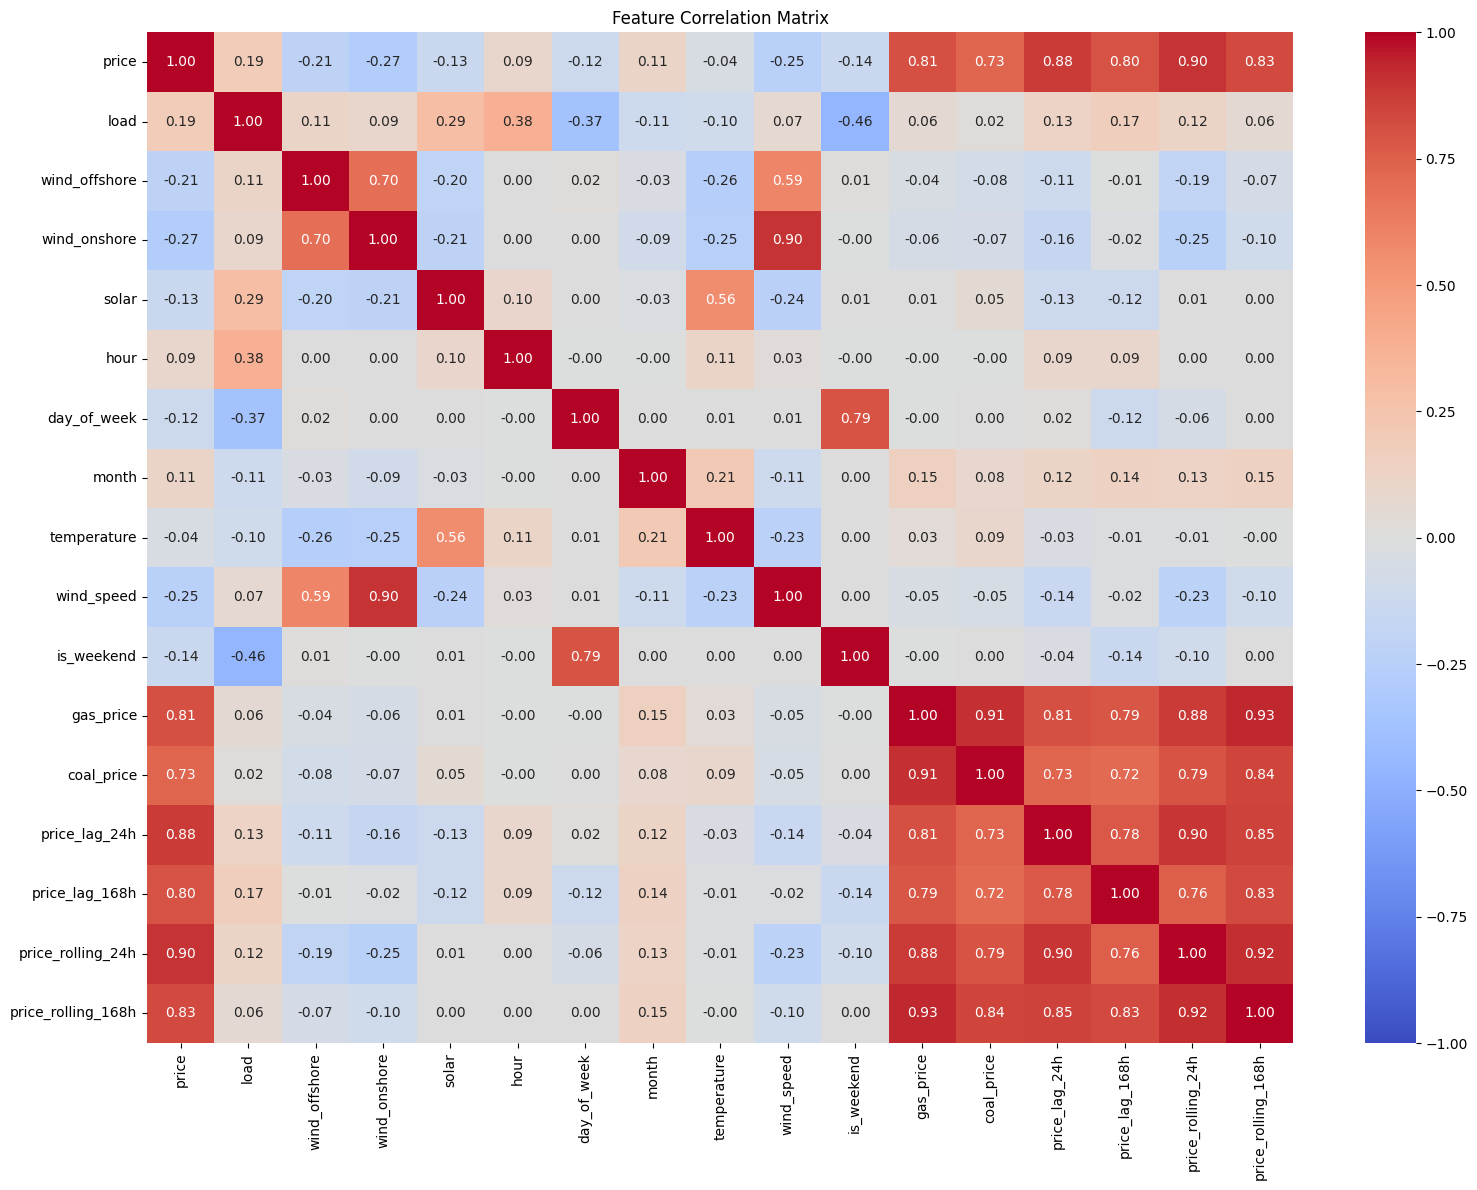

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns (exclude timestamp)
numeric_cols = df_final.select_dtypes(include=['float32', 'float64', 'int32', 'bool']).columns

# Correlation matrix
corr_matrix = df_final[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [31]:
# Drop only the clear problems
df_finall = df_final.drop(columns=["wind_speed", "is_weekend"])
df_finall.columns

Index(['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar',
       'hour', 'day_of_week', 'month', 'temperature', 'gas_price',
       'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h',
       'price_rolling_168h'],
      dtype='object')

In [32]:
# adding co2 price

In [33]:
icap = pd.read_csv("../data/icap-graph-price-data-2019-01-07-2025-12-05.csv")  # ili .xlsx

print(icap.shape)
print(icap.head(10))
print(icap.dtypes)
print(icap.isnull().sum())


(1550, 7)
   Unnamed: 0 European Union Emissions Trading System (from 2019, download)   
0        Date                              Exchange rate EUR/EUR             \
1  2019-01-07                                                  1              
2  2019-01-08                                                  1              
3  2019-01-10                                                  1              
4  2019-01-14                                                  1              
5  2019-01-15                                                  1              
6  2019-01-16                                                  1              
7  2019-01-17                                                  1              
8  2019-01-21                                                  1              
9  2019-01-22                                                  1              

              Unnamed: 2       Unnamed: 3      Unnamed: 4        Unnamed: 5     
0  Exchange rate EUR/USD  Market Curren

In [34]:
# Fix headers
icap.columns = icap.iloc[0]
icap = icap.drop(0).reset_index(drop=True)

# Keep only Date and Primary Market (CO2 price)
co2 = icap[["Date", "Primary Market"]].copy()
co2.columns = ["timestamp", "co2_price"]

# Fix types
co2["timestamp"] = pd.to_datetime(co2["timestamp"])
co2["co2_price"] = pd.to_numeric(co2["co2_price"], errors="coerce")

# Fill NaNs (weekends/missing auction days)
co2["co2_price"] = co2["co2_price"].ffill()

print(co2.shape)
print(co2.head(5))
print(f"Range: {co2['timestamp'].min()} to {co2['timestamp'].max()}")
print(f"Nulls: {co2.isnull().sum()}")

(1549, 2)
   timestamp  co2_price
0 2019-01-07      23.01
1 2019-01-08      22.40
2 2019-01-10      21.40
3 2019-01-14      21.95
4 2019-01-15      22.55
Range: 2019-01-07 00:00:00 to 2025-12-05 00:00:00
Nulls: timestamp    0
co2_price    0
dtype: int64


In [35]:
# Resample daily → hourly
co2_hourly = resample_to_hourly(co2)
co2_hourly["timestamp"] = pd.to_datetime(co2_hourly["timestamp"]).dt.tz_localize(None)

# Merge
df_final = df_final.merge(co2_hourly, on="timestamp", how="left")

# Fill missing (first few days + last 90 days)
df_final["co2_price"] = df_final["co2_price"].ffill().bfill()

print(f"Nulls: {df_final.isnull().sum().sum()}")
print(f"Shape: {df_final.shape}")

Nulls: 0
Shape: (62777, 19)


In [36]:
df_final.head(2)

,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,co2_price
0,2019-01-08 00:00:00,17.94,51472.75,4520.75,32832.0,0.0,0,1,1,5.000,38.297379,False,22.09,82.150002,46.03,28.32,50.642083,39.621845,22.4
1,2019-01-08 01:00:00,20.91,49815.00,4397.00,33236.5,0.0,1,1,1,5.125,42.214985,False,22.09,82.150002,47.98,10.07,49.514167,39.686369,22.4


In [37]:
# adding holiday feature, holidays package bydefault takes only federal holidays; holidays which are in all federal countries in Germany

import holidays

de_holidays = holidays.Germany(years = range(2019, 2027))

df_final["is_holiday"] = df_final["timestamp"].dt.date.apply(lambda d: d in de_holidays)
df_final["is_hol_or_week"] = df_final["is_weekend"] | df_final["is_holiday"]

df_final.columns.tolist()

['timestamp',
 'price',
 'load',
 'wind_offshore',
 'wind_onshore',
 'solar',
 'hour',
 'day_of_week',
 'month',
 'temperature',
 'wind_speed',
 'is_weekend',
 'gas_price',
 'coal_price',
 'price_lag_24h',
 'price_lag_168h',
 'price_rolling_24h',
 'price_rolling_168h',
 'co2_price',
 'is_holiday',
 'is_hol_or_week']

In [38]:
# 1. Christmas 2022 (Sunday) — should be weekend AND holiday
print("Christmas 2022:")
print(df_final[df_final["timestamp"].dt.date == pd.Timestamp("2022-12-25").date()]
      [["timestamp", "is_weekend", "is_holiday", "is_hol_or_week"]].head(3))

# 2. Regular Monday — should be all False
print("\nRegular Monday (2022-01-03):")
print(df_final[df_final["timestamp"].dt.date == pd.Timestamp("2022-01-03").date()]
      [["timestamp", "is_weekend", "is_holiday", "is_hol_or_week"]].head(3))

# 3. Labour Day 2023 (Wednesday) — holiday but NOT weekend
print("\nLabour Day 2023 (Wednesday):")
print(df_final[df_final["timestamp"].dt.date == pd.Timestamp("2023-05-01").date()]
      [["timestamp", "is_weekend", "is_holiday", "is_hol_or_week"]].head(3))

# 4. Regular Saturday — weekend but NOT holiday
print("\nRegular Saturday (2022-01-08):")
print(df_final[df_final["timestamp"].dt.date == pd.Timestamp("2022-01-08").date()]
      [["timestamp", "is_weekend", "is_holiday", "is_hol_or_week"]].head(3))

Christmas 2022:
                timestamp  is_weekend  is_holiday  is_hol_or_week
34752 2022-12-25 00:00:00        True        True            True
34753 2022-12-25 01:00:00        True        True            True
34754 2022-12-25 02:00:00        True        True            True

Regular Monday (2022-01-03):
                timestamp  is_weekend  is_holiday  is_hol_or_week
26202 2022-01-03 00:00:00       False       False           False
26203 2022-01-03 01:00:00       False       False           False
26204 2022-01-03 02:00:00       False       False           False

Labour Day 2023 (Wednesday):
                timestamp  is_weekend  is_holiday  is_hol_or_week
37799 2023-05-01 00:00:00       False        True            True
37800 2023-05-01 01:00:00       False        True            True
37801 2023-05-01 02:00:00       False        True            True

Regular Saturday (2022-01-08):
                timestamp  is_weekend  is_holiday  is_hol_or_week
26322 2022-01-08 00:00:00        T

In [39]:
####

In [40]:
# Helper function to clean numeric columns
def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(",", ""), errors="coerce")

# ── Actual Generation ─────────────────────────────────────────────
gen = pd.concat([
    pd.read_csv("../data/Actual_generation_201901010000_202201010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Actual_generation_202201010000_202501010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Actual_generation_202412310000_202603060000_Hour.csv", sep=";")
], ignore_index=True).drop_duplicates(subset="Start date", keep="first")

gen["timestamp"] = pd.to_datetime(gen["Start date"])
gen_cols = [c for c in gen.columns if "MWh" in c]
for col in gen_cols:
    gen[col] = clean_numeric(gen[col])
gen["total_generation"] = gen[gen_cols].sum(axis=1)

# ── Cross-border ──────────────────────────────────────────────────
cross = pd.concat([
    pd.read_csv("../data/Cross-border_physical_flows_201901010000_202201010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Cross-border_physical_flows_202201010000_202501010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Cross-border_physical_flows_202501010000_202603060000_Hour.csv", sep=";")
], ignore_index=True).drop_duplicates(subset="Start date", keep="first")

cross["timestamp"] = pd.to_datetime(cross["Start date"])
cross["net_export"] = clean_numeric(cross["Net export [MWh] Calculated resolutions"])

# ── Merge ─────────────────────────────────────────────────────────
df_final = df_final.merge(gen[["timestamp", "total_generation"]], on="timestamp", how="left")
df_final = df_final.merge(cross[["timestamp", "net_export"]], on="timestamp", how="left")

# ── Check ─────────────────────────────────────────────────────────
print(f"Shape: {df_final.shape}")
print(f"Nulls:\n{df_final.isnull().sum()}")

C:\Users\Josip\AppData\Local\Temp\ipykernel_16812\15579644.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gen["timestamp"] = pd.to_datetime(gen["Start date"])
C:\Users\Josip\AppData\Local\Temp\ipykernel_16812\15579644.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cross["timestamp"] = pd.to_datetime(cross["Start date"])


Shape: (62777, 23)
Nulls:
timestamp                 0
price                     0
load                      0
wind_offshore             0
wind_onshore              0
solar                     0
hour                      0
day_of_week               0
month                     0
temperature               0
wind_speed                0
is_weekend                0
gas_price                 0
coal_price                0
price_lag_24h             0
price_lag_168h            0
price_rolling_24h         0
price_rolling_168h        0
co2_price                 0
is_holiday                0
is_hol_or_week            0
total_generation          0
net_export            15037
dtype: int64


In [41]:
print(cross["net_export"].isnull().sum())
print(cross[cross["net_export"].isnull()]["timestamp"].dt.year.value_counts().sort_index())

15198
timestamp
2019    8759
2020    6431
2023       8
Name: count, dtype: int64


In [42]:
export_cols = [c for c in cross.columns if "export" in c.lower() and "Net" not in c]
import_cols = [c for c in cross.columns if "import" in c.lower()]

print(export_cols)
print(import_cols)

# Check nulls in these columns for 2019
print(cross[cross["timestamp"].dt.year == 2019][export_cols].isnull().sum())

['Switzerland (export) [MWh] Calculated resolutions', 'Denmark (export) [MWh] Calculated resolutions', 'Czech Republic (export) [MWh] Calculated resolutions', 'Luxembourg (export) [MWh] Calculated resolutions', 'Sweden (export) [MWh] Calculated resolutions', 'Austria (export) [MWh] Calculated resolutions', 'France (export) [MWh] Calculated resolutions', 'Poland (export) [MWh] Calculated resolutions', 'Norway (export) [MWh] Calculated resolutions', 'Belgium (export) [MWh] Calculated resolutions', 'net_export']
['Netherlands (import) [MWh] Calculated resolutions', 'Switzerland (import) [MWh] Calculated resolutions', 'Denmark (import) [MWh] Calculated resolutions', 'Czech Republic (import) [MWh] Calculated resolutions', 'Luxembourg (import) [MWh] Calculated resolutions', 'Sweden (import) [MWh] Calculated resolutions', 'Austria (import) [MWh] Calculated resolutions', 'France (import) [MWh] Calculated resolutions', 'Poland (import) [MWh] Calculated resolutions', 'Norway (import) [MWh] Calcu

In [43]:
# Clean all export and import columns
for col in export_cols + import_cols:
    cross[col] = clean_numeric(cross[col])

# Calculate net_export manually: sum of exports - sum of imports
cross["net_export"] = cross[export_cols].sum(axis=1) - cross[import_cols].sum(axis=1)

# Verify
print(f"Nulls net_export: {cross['net_export'].isnull().sum()}")
print(cross[["timestamp", "net_export"]].head(3))

# Re-merge into df_final
df_final = df_final.drop(columns=["net_export"])
df_final = df_final.merge(cross[["timestamp", "net_export"]], on="timestamp", how="left")

print(f"\nShape: {df_final.shape}")
print(f"Nulls net_export: {df_final['net_export'].isnull().sum()}")

Nulls net_export: 0
            timestamp  net_export
0 2019-01-01 00:00:00     12714.0
1 2019-01-01 01:00:00     11964.0
2 2019-01-01 02:00:00     11688.0

Shape: (62777, 23)
Nulls net_export: 0


In [44]:
df_final.columns.tolist()

['timestamp',
 'price',
 'load',
 'wind_offshore',
 'wind_onshore',
 'solar',
 'hour',
 'day_of_week',
 'month',
 'temperature',
 'wind_speed',
 'is_weekend',
 'gas_price',
 'coal_price',
 'price_lag_24h',
 'price_lag_168h',
 'price_rolling_24h',
 'price_rolling_168h',
 'co2_price',
 'is_holiday',
 'is_hol_or_week',
 'total_generation',
 'net_export']

In [ ]:
# adding gas, coal and nuclear generation